# Telco Customer Churn Prediction

Acquiring a new customer costs a lot more than keeping an existing one, so a telecom company wants to know **who is about to leave before they actually leave**. This project builds a classifier on the public Telco Customer Churn dataset and follows the whole workflow: cleaning, exploratory analysis, preprocessing, model building and tuning, error analysis, interpretation, and packaging the final model as a reusable pipeline.

**Dataset:** 7,043 customers, 21 columns (demographics, account information, subscribed services, monthly and total charges, and the `Churn` label). The CSV is expected in the same folder as this notebook.

**Target:** `Churn` (Yes/No). About 26.5% of customers churned, so the classes are imbalanced.

**Modelling choice that drives the project:** a customer who leaves without being flagged costs more than a retention offer sent to someone who would have stayed. I therefore treat **recall on the churn class** as the main metric and watch precision and F1 alongside it, rather than relying on accuracy.

### Results at a glance (validation set, 1,409 customers)

| Model | Accuracy | Recall | Precision | F1 |
|---|---|---|---|---|
| Always predict "No churn" | 0.735 | 0.000 | - | - |
| KNN (k=5) | 0.758 | 0.508 | 0.548 | 0.527 |
| KNN (k=5) + SMOTE | 0.705 | 0.701 | 0.463 | 0.557 |
| KNN (k=17, distance-weighted) + SMOTE | 0.700 | **0.743** | 0.460 | 0.569 |
| Logistic Regression + SMOTE | 0.757 | 0.706 | 0.531 | 0.606 |

### Contents
1. Data overview
2. Data cleaning
3. Exploratory data analysis
4. Preprocessing
5. Modelling
6. Error analysis
7. Model interpretation
8. Final pipeline and prediction
9. Key findings, limitations and next steps

## 1. Data overview

Load the data and check its size, column names and types.

In [2]:
import pandas as pd

df=pd.read_csv('Telco-Customer-churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

The table has one row per customer and 21 columns. `customerID` is an identifier, `SeniorCitizen` is already 0/1, and `tenure`, `MonthlyCharges` are numeric. Everything else is categorical text. One thing stands out in the `info()` output: **`TotalCharges` is stored as text (`str`) even though it should be a number.**

## 2. Data cleaning

Standard checks first: missing values, duplicated rows, and whether `customerID` really is unique.

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['customerID'].duplicated().sum()

np.int64(0)

There are no missing values, no duplicate rows and no repeated customer IDs. The `TotalCharges` column still needs attention, though. `isnull()` does not flag blank strings, so the check below returns zero even though the column has the wrong type. The blanks are replaced with 0 and the column is converted to a float. Blank values belong to customers with `tenure = 0` (11 of them, see section 3.3) who have not been billed yet, so 0 is a sensible fill. Using `errors='coerce'` and then re-checking for nulls confirms nothing else in the column was malformed.

In [8]:
df['TotalCharges'].isnull().sum()


np.int64(0)

In [9]:
df['TotalCharges']=df['TotalCharges'].replace(' ',0) 

In [10]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [11]:
df['TotalCharges'].dtype

dtype('float64')

In [12]:
df['TotalCharges'].isnull().sum()


np.int64(0)

## 3. Exploratory data analysis

The questions for this section: how imbalanced is the target, and which customer attributes separate churners from non-churners?

### 3.1 Target distribution

In [13]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df['Churn'].value_counts(normalize = True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

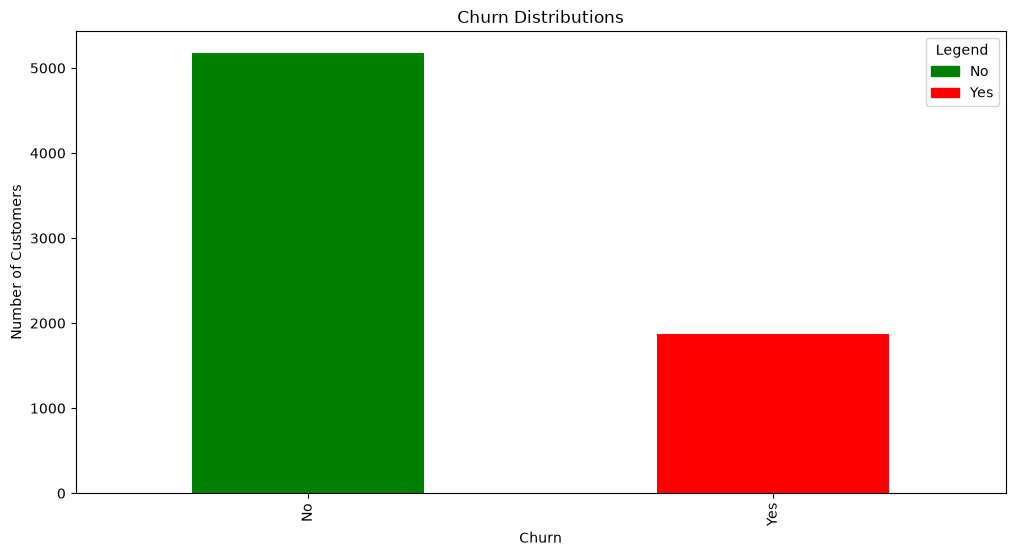

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.figure(figsize=(12,6))
c=['green','red']
df['Churn'].value_counts().plot(kind='bar',color=c)
no_patch = mpatches.Patch(color='green', label='No')
yes_patch = mpatches.Patch(color='red', label='Yes')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.title('Churn Distributions')
plt.legend(handles=[no_patch, yes_patch], frameon=True, loc=1, title='Legend')
plt.show()

1,869 of 7,043 customers churned (26.5%), against 5,174 who stayed (73.5%). Two consequences:

- A model that always answers "No churn" would already be right 73.5% of the time, so **accuracy alone cannot tell us whether a model is useful**.
- The minority class needs explicit handling during training (SMOTE is used later).

### 3.2 Contract type

In [16]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

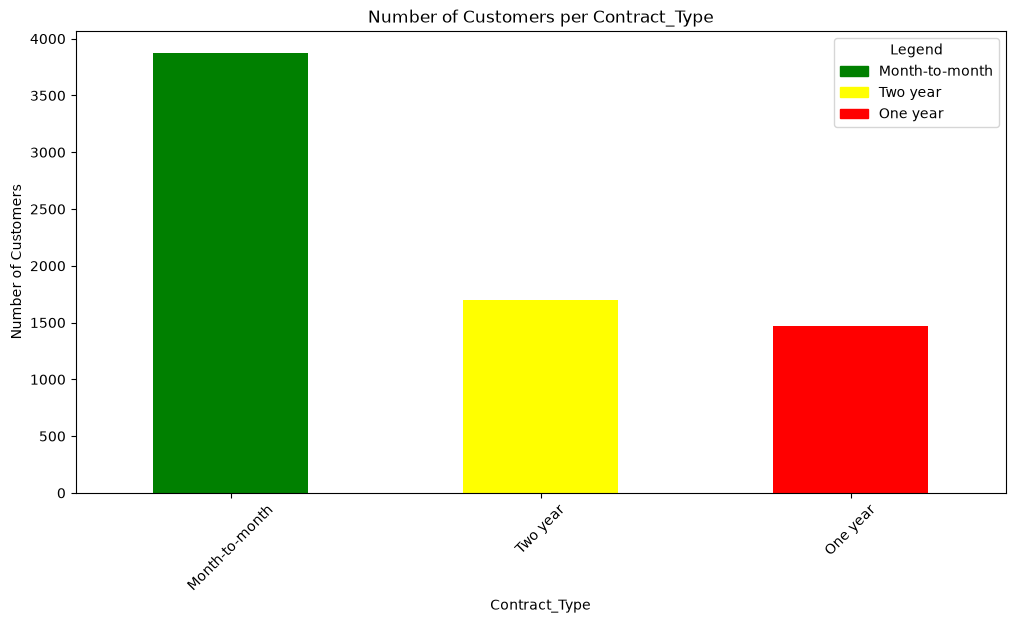

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.figure(figsize=(12,6))
c=['green','yellow','red']
df['Contract'].value_counts().plot(kind='bar',color=c)
idx=df['Contract'].value_counts().index
month_to_month_patch = mpatches.Patch(color='green', label=idx[0])
Two_Year_patch = mpatches.Patch(color='yellow', label=idx[1])
One_Year_patch = mpatches.Patch(color='red', label=idx[2])
plt.xlabel('Contract_Type')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Contract_Type')
plt.legend(handles=[month_to_month_patch,Two_Year_patch,One_Year_patch ], frameon=True, loc=1, title='Legend')

ax=plt.gca()
for i in ax.get_xticklabels():
    i.set_rotation(45)
plt.show()

In [18]:
df.groupby('Contract')['Churn'].value_counts(normalize=True)*100

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.730482
                Yes      11.269518
Two year        No       97.168142
                Yes       2.831858
Name: proportion, dtype: float64

Contract type has the clearest relationship with churn in the whole dataset. More than half of the customers (3,875) are on month-to-month contracts, and that group churns at **42.7%**, compared with 11.3% for one-year and only 2.8% for two-year contracts.

### 3.3 Tenure

`tenure` (months with the company) is grouped into four buckets: just joined (0 months), short term (1-12), mid term (13-48) and long term (49+). The buckets are used only for exploration; the model itself uses the raw `tenure` value.

In [19]:
df['tenure_type'] = pd.cut(
    df['tenure'],
    bins=[-1, 0, 12, 48, 100],
    labels=['just_joined', 'short_term_customer', 'mid_term_customer', 'long_time_customer']
)

In [20]:
df.groupby('Churn')['tenure_type'].value_counts(normalize=True)*100

Churn  tenure_type        
No     long_time_customer     39.157325
       mid_term_customer      38.635485
       short_term_customer    21.994588
       just_joined             0.212601
Yes    short_term_customer    55.484216
       mid_term_customer      33.119315
       long_time_customer     11.396469
       just_joined             0.000000
Name: proportion, dtype: float64

In [21]:
df.groupby('tenure_type')['Churn'].value_counts(normalize=True)*100

tenure_type          Churn
just_joined          No       100.000000
short_term_customer  No        52.321839
                     Yes       47.678161
mid_term_customer    No        76.355997
                     Yes       23.644003
long_time_customer   No        90.486824
                     Yes        9.513176
Name: proportion, dtype: float64

Churn drops quickly as customers stay longer. **47.7%** of short-term customers (1-12 months) leave, against 23.6% of mid-term and 9.5% of long-term customers. Short-term customers make up 55% of all churners even though they are only about 31% of the customer base. The 11 customers with zero tenure did not churn, but the group is too small to read anything into.

### 3.4 Monthly charges

In [22]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

Text(0.5, 1.0, 'MonthlyCharges vs Churn')

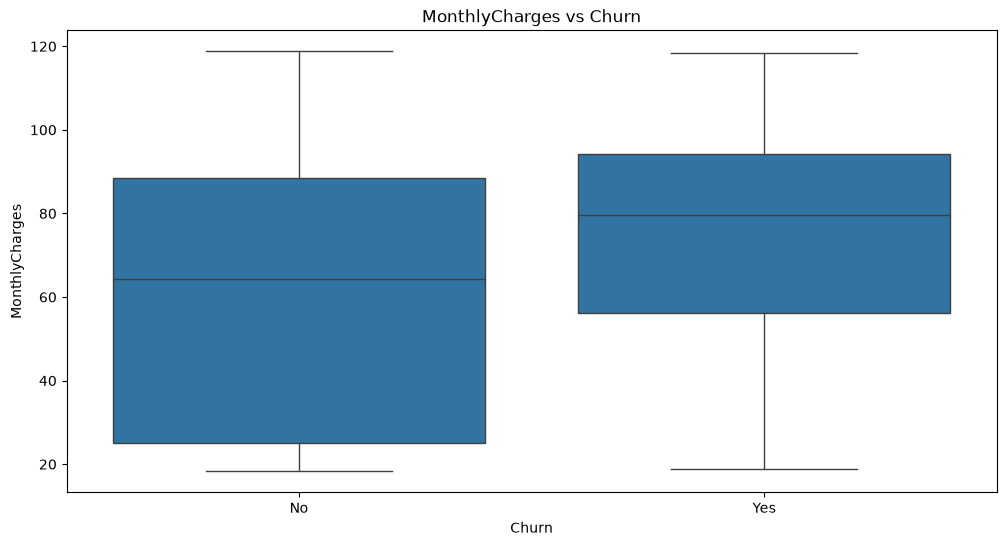

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x='Churn',y='MonthlyCharges')
plt.xlabel('Churn')
plt.ylabel('MonthlyCharges')
plt.title('MonthlyCharges vs Churn')

Churners pay more on average: about **$74.44 per month** versus **$61.27** for customers who stayed. The boxplot shows the shift clearly: the median is roughly $64 for retained customers and roughly $79 for churners, and the biggest gap is at the low end, where many retained customers sit on cheap plans (the lower quartile is about $25, against about $56 for churners).

**Summary of the EDA**

- Churn rate is 26.5%, so the data is imbalanced.
- Month-to-month contracts are the biggest risk factor (42.7% churn).
- Customers in their first year are the most likely to leave (47.7% churn).
- Churners tend to have higher monthly bills.

## 4. Preprocessing

Steps, in order:

1. Check how many distinct values each text column has. Two-level columns can be mapped straight to 0/1, columns with three or more levels need one-hot encoding.
2. Drop `tenure_type` (created for EDA only).
3. Encode: Yes/No columns and `gender` (Female = 1, Male = 0) are mapped to 0/1; the remaining categorical columns are one-hot encoded with `drop_first=True` to avoid redundant columns.
4. Split into train / validation / test with a **60 / 20 / 20 stratified split** (`random_state=42`) so each part keeps the 26.5% churn rate.
5. Scale `tenure`, `MonthlyCharges` and `TotalCharges` with `StandardScaler`. The scaler is **fitted on the training set only** and then applied to validation and test, so no information leaks from the held-out data.

The cell that performs steps 3-5 is kept as one block so the whole preprocessing can be re-run from top to bottom in one go.

In [24]:
df.select_dtypes(include='object').nunique()


C:\Users\Neha2004\AppData\Local\Temp\ipykernel_15408\2001172712.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique()


customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
Churn                  2
dtype: int64

In [25]:
df=df.drop(columns=['tenure_type'])

In [26]:
#encoding
cols=['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in df[cols]:
    df[col]=df[col].map({'Yes':1,'No':0})
df['gender']=df['gender'].map({'Female':1,'Male':0})
#one hot encoding
df=pd.get_dummies(df,columns=['Contract','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaymentMethod'], drop_first=True)
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})
# train_test_split
from sklearn.model_selection import train_test_split
temp_df,test_df=train_test_split(df,stratify=df['Churn'],random_state=42,test_size=0.2)

train_df,val_df=train_test_split(temp_df,stratify=temp_df['Churn'],random_state=42,test_size=0.25)

X_train=train_df.drop(columns=['customerID','Churn'])
y_train=train_df['Churn']

X_val=val_df.drop(columns=['customerID','Churn'])
y_val=val_df['Churn']

X_test=test_df.drop(columns=['customerID','Churn'])
y_test=test_df['Churn']
#Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[['tenure','MonthlyCharges','TotalCharges']]=scaler.fit_transform(X_train[['tenure','MonthlyCharges','TotalCharges']])

X_val[['tenure','MonthlyCharges','TotalCharges']]=scaler.transform(X_val[['tenure','MonthlyCharges','TotalCharges']])
X_test[['tenure','MonthlyCharges','TotalCharges']]=scaler.transform(X_test[['tenure','MonthlyCharges','TotalCharges']])

In [27]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_One year,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2312,0,0,0,0,-0.579543,1,0,-1.489929,-0.825501,1,...,0,1,0,1,0,1,0,0,0,1
5227,0,0,0,0,-1.025518,1,0,1.047953,-0.721184,0,...,0,0,0,0,1,0,1,0,1,0
6404,0,0,0,0,0.798927,1,1,1.484829,1.511956,0,...,1,0,1,0,1,0,1,0,1,0
88,1,0,1,1,0.555668,1,1,-1.494931,-0.595135,0,...,0,1,0,1,0,1,0,0,0,1
6496,0,1,1,0,0.312408,1,0,1.236377,0.790441,0,...,0,0,0,0,1,0,1,0,1,0


After encoding, the model sees 30 features. The numeric columns are now standardised (mean 0, unit variance) and everything else is 0/1.

## 5. Modelling

The plan is to start with a simple K-Nearest Neighbours baseline, deal with the class imbalance, tune the model, and finally compare against logistic regression. All comparisons use the validation set.

### 5.1 Baseline: KNN with k = 5

In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [29]:
predictions=knn.predict(X_val)

In [30]:
from sklearn.metrics import accuracy_score
accuracy_score(predictions,y_val)

0.7579843860894251

In [31]:
from sklearn.metrics import confusion_matrix
confusion_matrix(predictions,y_val)

array([[878, 184],
       [157, 190]])

In [32]:
from sklearn.metrics import f1_score
f1_score(predictions,y_val)

0.5270457697642164

Accuracy of 75.8% looks fine, but the majority-class baseline already gets 73.5%. The confusion matrix shows why: only 190 of the 374 churners in the validation set were found (recall of about 0.51), and the F1 score is 0.527. The model is good at recognising customers who stay and mediocre at the ones we actually care about.

*Note on reading the matrix: this call passes `(predictions, y_val)`, so rows are predicted classes and columns are actual classes.*

### 5.2 Handling class imbalance with SMOTE

SMOTE creates synthetic minority-class examples by interpolating between existing churners. It is applied to the **training data only**; the validation set stays untouched so the evaluation reflects real class proportions.

In [33]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_resampled,y_resampled= smote.fit_resample(X_train,y_train)
knn_smote=KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_resampled,y_resampled)
predictions=knn_smote.predict(X_val)
for i in range(10):
    print(predictions[i])


1
1
1
1
0
1
0
0
1
0


In [34]:
from sklearn.metrics import accuracy_score 
accuracy_score(predictions,y_val)

0.7047551454932577

In [35]:
from sklearn.metrics import confusion_matrix
confusion_matrix(predictions,y_val)

array([[731, 112],
       [304, 262]])

Accuracy falls to 70.5%, but the model now finds 262 of the 374 churners (recall about 0.70, up from 0.51). Precision drops to 0.46 because more loyal customers get flagged as well. This is the trade-off we accepted on purpose: a false alarm costs a retention offer, a missed churner costs a customer.

*Same convention as before: rows are predicted classes, columns are actual classes.*

### 5.3 Hyperparameter tuning

A grid search over `n_neighbors` and `weights`, scored on recall with 5-fold cross-validation. The search points to k = 9 with distance weighting, which is evaluated next.

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid={ 'n_neighbors': [3, 5, 7, 9, 11, 15],
             'weights':['uniform','distance']}
grid=GridSearchCV(KNeighborsClassifier(),param_grid,scoring='recall',cv=5)
grid.fit(X_resampled,y_resampled)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informatio

In [37]:

knn_grid=KNeighborsClassifier(n_neighbors=9,weights='distance')
knn_grid.fit(X_resampled,y_resampled)
predictions=knn_grid.predict(X_val)
accuracy_score(predictions,y_val)

0.6976579134137686

In [38]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_val,predictions)

array([[718, 317],
       [109, 265]])

In [39]:
from sklearn.metrics import recall_score

recall_score(y_val, predictions)

0.7085561497326203

In [40]:
from sklearn.metrics import precision_score

precision_score(y_val, predictions)

0.45532646048109965

Recall improves slightly (0.709) with a similar precision (0.455). To see the effect of `k` more directly, I sweep odd values from 1 to 29 (distance-weighted, SMOTE-trained) and plot recall, precision and F1 on the validation set.

In [41]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import  f1_score

k_range=range(1,31,2)
recall_scores=[]
precision_scores=[]
f1_scores=[]
for k in k_range:
    model=KNeighborsClassifier(n_neighbors=k,weights='distance')
    model.fit(X_resampled,y_resampled)
    pred=model.predict(X_val)
    recall_scores.append(recall_score(y_val,pred))
    precision_scores.append(precision_score(y_val,pred))
    f1_scores.append(f1_score(y_val,pred))

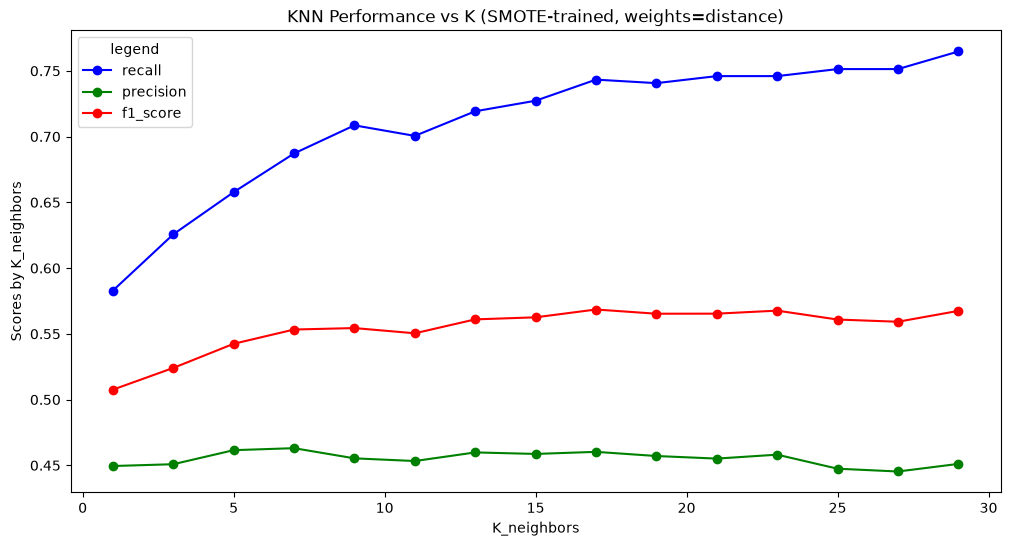

In [42]:
plt.figure(figsize=(12,6))

plt.plot(k_range,recall_scores,'-bo',label='recall')
plt.plot(k_range,precision_scores,'-go',label='precision')
plt.plot(k_range,f1_scores,'-ro',label='f1_score')
plt.legend(frameon=True,title='legend',loc=2)
plt.xlabel('K_neighbors')
plt.ylabel('Scores by K_neighbors')
plt.title('KNN Performance vs K (SMOTE-trained, weights=distance)')
plt.show()

Recall rises steadily as `k` grows (from about 0.58 at k=1 to about 0.76 at k=29), while precision stays flat around 0.45. F1 peaks at **k = 17**, so that value is used for the final KNN.

In [43]:
knn_new=KNeighborsClassifier(n_neighbors=17,weights='distance')
knn_new.fit(X_resampled,y_resampled)
pred_new=knn_new.predict(X_val)
print('accuracy_score',':',accuracy_score(pred_new,y_val))
print('recall_score',':',recall_score(y_val, pred_new))
print('precision_score',':',precision_score(y_val, pred_new))
print('f1_score',':',f1_score(y_val, pred_new))

accuracy_score : 0.7004968062455642
recall_score : 0.7433155080213903
precision_score : 0.4602649006622517
f1_score : 0.5685071574642127


In [44]:
confusion_matrix(y_val,pred_new)

array([[709, 326],
       [ 96, 278]])

With k = 17 the model catches 278 of 374 churners (recall 0.743) at the cost of 326 false alarms (precision 0.460).

### 5.4 Comparison with logistic regression

Logistic regression is trained on the same SMOTE-resampled data as a second, simple and interpretable reference model.

In [45]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression(max_iter=1000)
log_reg.fit(X_resampled,y_resampled)
pred_log=log_reg.predict(X_val)
log_coeff=log_reg.coef_
log_intercept=log_reg.intercept_
print(f'accuracy_score :{accuracy_score(pred_log,y_val)} \n recall :  {recall_score(y_val,pred_log)} \n precision : {precision_score(y_val,pred_log)}\n f1_score : {f1_score(y_val,pred_log)}')


accuracy_score :0.7565649396735273 
 recall :  0.7058823529411765 
 precision : 0.5311871227364185
 f1_score : 0.6061997703788748


### 5.5 Model comparison

| Model | Accuracy | Recall | Precision | F1 |
|---|---|---|---|---|
| KNN (k=5) | 0.758 | 0.508 | 0.548 | 0.527 |
| KNN (k=5) + SMOTE | 0.705 | 0.701 | 0.463 | 0.557 |
| KNN (k=9, distance) + SMOTE | 0.698 | 0.709 | 0.455 | 0.554 |
| KNN (k=17, distance) + SMOTE | 0.700 | **0.743** | 0.460 | 0.569 |
| Logistic Regression + SMOTE | **0.757** | 0.706 | **0.531** | **0.606** |

The two candidates make different trade-offs. Tuned KNN has the highest recall, so it catches the most churners. Logistic regression is more balanced: it is clearly better on precision, F1 and accuracy while giving up about four points of recall. Because the goal of this project is to miss as few churners as possible, **KNN with k = 17 is carried forward** into the error analysis and the final pipeline. If retention offers were expensive, logistic regression would be the better choice.

## 6. Error analysis

Which churners does the final KNN miss? False negatives (churners predicted as staying) are compared with true positives (churners correctly caught). The feature values are standardised, so 0 is the average customer.

In [46]:
false_negatives = X_val[(y_val == 1) & (pred_new == 0)]

In [47]:
false_negatives.shape



(96, 30)

In [48]:
true_positives = X_val[(y_val == 1) & (pred_new == 1)]

In [49]:
print(false_negatives['tenure'].mean())
print(true_positives['tenure'].mean())

-0.045723496303889305
-0.6562541031329231


In [50]:
print(false_negatives['MonthlyCharges'].mean())
print(true_positives['MonthlyCharges'].mean())

0.044573316828389525
0.4798692780974716


The model misses 96 of the 374 churners. The two groups look different:

| | Tenure (scaled mean) | MonthlyCharges (scaled mean) |
|---|---|---|
| Caught churners (true positives) | -0.656 | +0.480 |
| Missed churners (false negatives) | -0.046 | +0.045 |

Caught churners are typically new customers with high bills, so they sit far from the loyal customers in feature space and are easy for KNN to isolate. Missed churners look like ordinary customers, with average tenure and average charges, and get outvoted by their loyal neighbours. Any model built only on these features will struggle with that group; picking them up would need additional signals, for example usage or support-call data, which this dataset does not contain.

## 7. Model interpretation

KNN has no built-in feature importance, so permutation importance is used: shuffle one feature at a time on the validation set and measure how much recall drops (10 repeats per feature).

In [51]:
from sklearn.inspection import permutation_importance
result=permutation_importance(knn_new,X_val,y_val,scoring='recall',n_repeats=10,random_state=42)
importance_df=pd.DataFrame({ 'features': X_val.columns,
                             'importance':result.importances_mean}).sort_values('importance',ascending=False)
print(importance_df.head(10))

                          features  importance
4                           tenure    0.022460
7                   MonthlyCharges    0.009893
18                OnlineBackup_Yes    0.008289
11  MultipleLines_No phone service    0.004813
5                     PhoneService    0.004813
29      PaymentMethod_Mailed check    0.000535
0                           gender    0.000535
2                          Partner   -0.004278
10               Contract_Two year   -0.004545
24                 StreamingTV_Yes   -0.004545


- **`tenure`** (0.022) and **`MonthlyCharges`** (0.010) are the most influential features by a clear margin, which agrees with the EDA and with the error analysis.
- `OnlineBackup_Yes` (0.008) comes next. `MultipleLines_No phone service` and `PhoneService` have identical scores (0.0048) because they encode the same fact, whether the customer has phone service at all.
- The remaining features are close to zero, and a few are slightly negative (`Contract_Two year`, `StreamingTV_Yes`). Values this small are noise, not evidence that a feature hurts the model.

One point worth noting: contract type was the strongest signal in the EDA but barely registers here. A plausible reason is that KNN works with distances, and a single 0/1 column contributes little next to standardised numeric features. A model that can use categorical splits directly (tree-based models) might make better use of it.

## 8. Final pipeline and prediction

Up to this point the encoding and scaling were done by hand. For a model that can be reused, all of that should live in one object. The steps below rebuild the workflow from the raw CSV with a scikit-learn `ColumnTransformer` (scale numeric columns, one-hot encode categorical ones) and a `Pipeline`, using the same 60/20/20 split.

The first version has no SMOTE, as a reference point.

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('Telco-Customer-Churn.csv')   # use your own file path
df['TotalCharges'] = df['TotalCharges'].replace(' ', 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})
df = df.drop(columns=['customerID'])

temp_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Churn'], random_state=42)
train_df, val_df = train_test_split(temp_df, test_size=0.25, stratify=temp_df['Churn'], random_state=42)

X_train_raw = train_df.drop(columns=['Churn'])
y_train_raw = train_df['Churn']
X_val_raw = val_df.drop(columns=['Churn'])
y_val_raw = val_df['Churn']
X_test_raw = test_df.drop(columns=['Churn'])
y_test_raw = test_df['Churn']

In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define column groups
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender','SeniorCitizen','Partner','Dependents','PhoneService',
                         'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
                         'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
                         'Contract','PaperlessBilling','PaymentMethod']

# Build preprocessor: scale numeric, one-hot encode categorical
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# Build full pipeline: preprocessing + model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=17, weights='distance'))
])

# Fit the ENTIRE pipeline on raw training data (no manual encoding/scaling needed!)
pipeline.fit(X_train_raw, y_train_raw)

# Predict on raw validation data
val_predictions = pipeline.predict(X_val_raw)

# Evaluate
print("Accuracy:", accuracy_score(y_val_raw, val_predictions))
print("Precision:", precision_score(y_val_raw, val_predictions))
print("Recall:", recall_score(y_val_raw, val_predictions))
print("F1:", f1_score(y_val_raw, val_predictions))

Accuracy: 0.772888573456352
Precision: 0.5838509316770186
Recall: 0.5026737967914439
F1: 0.5402298850574713


Without SMOTE the pipeline reproduces the baseline behaviour: good accuracy (0.773), weak recall (0.503). Next, SMOTE is added as a pipeline step using `imblearn`'s pipeline. This way, oversampling only happens while fitting and never touches validation or new data.

In [63]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Same preprocessor as before
full_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', KNeighborsClassifier(n_neighbors=17, weights='distance'))
])

full_pipeline.fit(X_train_raw, y_train_raw)
val_predictions = full_pipeline.predict(X_val_raw)

print("Accuracy:", accuracy_score(y_val_raw, val_predictions))
print("Precision:", precision_score(y_val_raw, val_predictions))
print("Recall:", recall_score(y_val_raw, val_predictions))
print("F1:", f1_score(y_val_raw, val_predictions))

Accuracy: 0.6863023420865862
Precision: 0.4462025316455696
Recall: 0.7540106951871658
F1: 0.5606361829025845


Validation results with SMOTE and k=17: accuracy 0.686, precision 0.446, recall 0.754, F1 0.561. Recall is up substantially from the no-SMOTE baseline (0.503), which was the point of adding SMOTE — precision drops a bit in exchange, but that's the trade-off decided on earlier: missing a churner costs more than a false alarm, so recall matters more here. These are the numbers k=17 was actually selected on, so they're expected to look slightly better than a fully honest estimate — the test set below is the real check.

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define column groups
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender','SeniorCitizen','Partner','Dependents','PhoneService',
                         'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
                         'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
                         'Contract','PaperlessBilling','PaymentMethod']

# Build preprocessor: scale numeric, one-hot encode categorical
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# Build full pipeline: preprocessing + model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=17, weights='distance'))
])

# Fit the ENTIRE pipeline on raw training data (no manual encoding/scaling needed!)
pipeline.fit(X_train_raw, y_train_raw)

# Predict on raw validation data
test_predictions = pipeline.predict(X_test_raw)

# Evaluate
print("Accuracy:", accuracy_score(y_test_raw, test_predictions))
print("Precision:", precision_score(y_test_raw, test_predictions))
print("Recall:", recall_score(y_test_raw, test_predictions))
print("F1:", f1_score(y_test_raw, test_predictions))

Accuracy: 0.7700496806245565
Precision: 0.5730994152046783
Recall: 0.5240641711229946
F1: 0.547486033519553


In [65]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Same preprocessor as before
full_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', KNeighborsClassifier(n_neighbors=17, weights='distance'))
])

full_pipeline.fit(X_train_raw, y_train_raw)
test_predictions = full_pipeline.predict(X_test_raw)

print("Accuracy:", accuracy_score(y_test_raw, test_predictions))
print("Precision:", precision_score(y_test_raw, test_predictions))
print("Recall:", recall_score(y_test_raw, test_predictions))
print("F1:", f1_score(y_test_raw, test_predictions))

Accuracy: 0.7111426543647977
Precision: 0.4737678855325914
Recall: 0.7967914438502673
F1: 0.5942173479561316


On the test set, the model identifies 298 of 374 actual churners (79.7% recall) — meaning the retention team would miss roughly 1 in 5 at-risk customers, while flagging some loyal customers along the way (47.4% precision). Given the earlier reasoning that a missed churner costs more than a wasted retention offer, this trade-off is reasonable for the stated business goal.

In [57]:
import joblib

joblib.dump(full_pipeline, 'churn_pipeline.pkl')

loaded_pipeline = joblib.load('churn_pipeline.pkl')

In [58]:
def predict_churn(customer_data, pipeline):
    """
    customer_data: a dictionary of one customer's raw feature values
    pipeline: the trained pipeline
    """
    df_input = pd.DataFrame([customer_data])
    prediction = pipeline.predict(df_input)[0]
    probability = pipeline.predict_proba(df_input)[0][1]
    
    result = "Yes" if prediction == 1 else "No"
    return f"Churn Prediction: {result}\nChurn Probability: {probability*100:.1f}%"

Example: a customer on a month-to-month contract, 5 months of tenure, fiber optic internet, no security, backup or tech support, paying $90.50 per month by electronic check. This profile matches the risk factors found in the EDA.

In [59]:
new_customer = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 5,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 90.5,
    'TotalCharges': 452.5
}

In [60]:
predict_churn(new_customer,loaded_pipeline)

'Churn Prediction: Yes\nChurn Probability: 94.1%'

The pipeline flags this customer as very likely to churn. Note that KNN probabilities are the share of neighbours voting for each class, so they are useful for ranking customers by risk but should not be read as calibrated probabilities.

## 9. Key findings, limitations and next steps

### Key findings

1. **Contract type is the strongest churn signal.** Month-to-month customers churn at 42.7%, one-year at 11.3% and two-year at 2.8%.
2. **The first year is the danger zone.** Customers with 1-12 months of tenure churn at 47.7%, and they make up 55% of all churners.
3. **Churners pay more.** Average monthly charge is about $74 for churners against $61 for retained customers.
4. **Accuracy is misleading here.** A model that always predicts "No churn" scores 73.5%, and the untuned KNN barely improves on that (75.8%) while finding only half of the churners.
5. **SMOTE and tuning lift recall from 0.51 to 0.74.** The price is precision of about 0.46, so roughly half of the flagged customers would not have left.
6. **Logistic regression is the more balanced model** (F1 0.606, precision 0.531) while KNN gives the highest recall. The choice between them depends on the cost of a retention offer.
7. **The model misses "average-looking" churners.** Those with typical tenure and charges are hard to separate from loyal customers using the available features.

### Business implications

- Offer incentives to move month-to-month customers onto one- or two-year contracts, especially in their first year.
- Put early-life customers with high monthly bills at the top of the retention call list.
- Use the model to rank customers by churn risk and contact the highest-risk group first, rather than treating the 0/1 prediction as final.

### Limitations

- Test set performance was measured once, after all tuning decisions were finalised. Accuracy 0.711, precision 0.474, recall 0.797, F1 0.594 — close to the validation numbers, so there's no sign the model overfit to the validation set during k selection. Still, this is a single test split rather than a distribution of scores, so some of this gap (test slightly outperforming validation) is likely down to chance rather than a real effect.

- The grid search ran on SMOTE-resampled data, so synthetic samples can appear in both the training and validation folds of the cross-validation. Its scores are optimistic, which is why k was refined on the real validation set afterwards rather than trusting the grid search score directly.

- Precision is low (about 0.45-0.47 depending on the split). In practice this means a large share of retention offers would go to customers who were never going to leave.

- The EDA covers contract, tenure and monthly charges. Other variables such as internet service type and payment method were not explored individually, and could contain additional signal.

- Results come from a single train/validation/test split; no repeated cross-validation of the final model was done, so the exact numbers would likely shift a little on a different random split.

### Next steps

- Score the final model on the held-out test set.
- Try tree-based models (Random Forest, gradient boosting), which can use categorical variables such as contract type more directly.
- Try class weights or a tuned decision threshold as an alternative to SMOTE.
- Put a cost on false negatives and false positives and choose the model and threshold that minimise expected cost.
- Calibrate the predicted probabilities before using them for anything beyond ranking.